# SHAP Analysis — UAVCAN Intrusion Dataset
**Method:** SHAP (SHapley Additive exPlanations)  
**Models:** Random Forest, 1D-CNN, Autoencoder  
**Dataset:** UAVCAN (Normal, Attack — binary CAN bus classification)  
**Goal:** Explain which features drive each model's predictions  
**Output:** shap_rf_global.png, shap_cnn_global.png, shap_ae_global.png, shap_results.json

In [1]:
# ============================================================
# Cell 2 — Load data and models:
# WHAT: Load preprocessed data and all 3 trained models
#       for SHAP explanation analysis
#
# WHY:  SHAP needs both the trained model and test data
#       to calculate feature importance scores.
#       TreeExplainer → fast SHAP for RF (tree-based)
#       GradientExplainer → for CNN (deep learning)
#       We use small sample (500) for speed — full dataset
#       would take hours to compute SHAP values
#
# HOW:  Step 1: load X_train, X_test, y_test
#       Step 2: load feature_names and label_classes
#       Step 3: load rf_model, cnn_model, ae_model
#       Step 4: create 500-row sample for SHAP computation
# ============================================================

import numpy as np
import pandas as pd
import shap
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
import json
import time

save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/UAVCAN/processed/"

# load data
X_train = np.load(save_path + "X_train.npy")
X_test  = np.load(save_path + "X_test.npy")
y_test  = pd.read_csv(save_path + "y_test.csv").squeeze()
feature_names = pd.read_csv(save_path + "feature_names.csv").squeeze().tolist()
label_classes = pd.read_csv(save_path + "label_classes.csv").squeeze().tolist()

# load all 3 trained models
rf_model  = joblib.load(save_path + "rf_model.joblib")
cnn_model = tf.keras.models.load_model(save_path + "cnn_model.keras")
ae_model  = tf.keras.models.load_model(save_path + "ae_model.keras")

# create small sample for SHAP — 500 rows is enough
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=500, replace=False)
X_sample   = X_test[sample_idx]
y_sample   = y_test.iloc[sample_idx]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Sample:  {X_sample.shape}")
print(f"Features: {len(feature_names)}")
print(f"Classes: {label_classes}")
print("Data and models loaded!")

2026-05-16 10:14:53.325307: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


X_train: (1422771, 10)
X_test:  (609759, 10)
Sample:  (500, 10)
Features: 10
Classes: ['Attack', 'Normal']
Data and models loaded!


In [2]:
# ============================================================
# Cell 3 — SHAP on Random Forest:
# WHAT: Calculate SHAP values for Random Forest model
#
# WHY:  TreeExplainer is the fastest and most accurate
#       SHAP method for tree-based models like RF.
#       SHAP values show how much each feature contributes
#       to pushing the prediction toward each attack class.
#       Positive SHAP = pushes toward this class
#       Negative SHAP = pushes away from this class
#
# HOW:  Step 1: create TreeExplainer using RF model
#       Step 2: calculate SHAP values for 500 samples
#       Step 3: shap_values shape = (500, features, classes)
#       Step 4: mean absolute SHAP = global importance
# ============================================================

print("Calculating SHAP values for Random Forest...")
start_time = time.time()

# TreeExplainer = optimized for tree models (RF, XGBoost etc)
rf_explainer  = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_sample)

elapsed_rf = round(time.time() - start_time, 2)
print(f"RF SHAP complete! Time: {elapsed_rf}s")
print(f"SHAP values type: {type(rf_shap_values)}")

if isinstance(rf_shap_values, list):
    print(f"Number of classes: {len(rf_shap_values)}")
    print(f"Shape per class: {rf_shap_values[0].shape}")
else:
    print(f"SHAP values shape: {rf_shap_values.shape}")

Calculating SHAP values for Random Forest...
RF SHAP complete! Time: 365.38s
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (500, 10, 2)


Generating RF SHAP plot...


/var/folders/28/cggd8l710jz37nj7nfdl032r0000gn/T/ipykernel_44465/2479200201.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


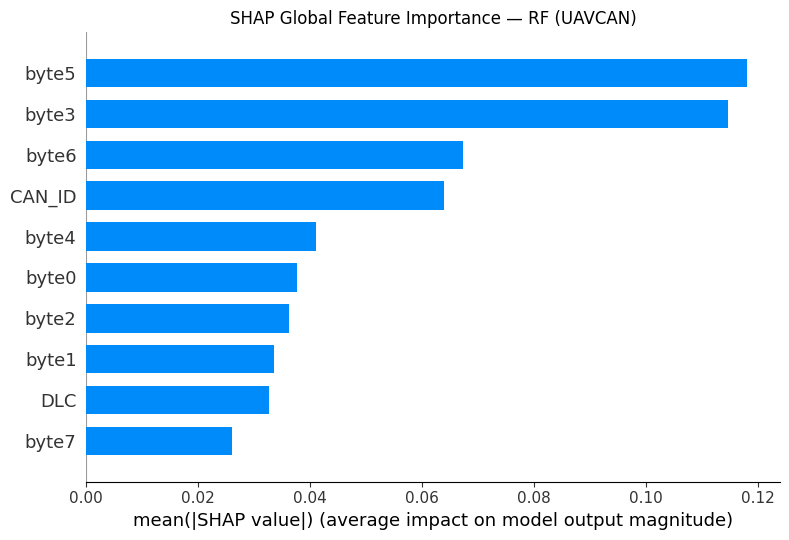

RF SHAP plot saved!

Top 10 Features — RF SHAP:
Rank   Feature                             SHAP Score          
--------------------------------------------------------------
  1    byte5                               0.118023
  2    byte3                               0.114664
  3    byte6                               0.067348
  4    CAN_ID                              0.063921
  5    byte4                               0.041003
  6    byte0                               0.037591
  7    byte2                               0.036186
  8    byte1                               0.033537
  9    DLC                                 0.032577
  10   byte7                               0.026016


In [3]:
# ============================================================
# Cell 4 — Plot RF SHAP:
# WHAT: Visualize RF SHAP global feature importance
#
# WHY:  Bar chart shows which features matter most OVERALL
#       across all attack classes combined.
#       Mean absolute SHAP = average impact on prediction
#       Higher bar = more important feature for RF model
#
# HOW:  Step 1: mean absolute SHAP across all classes
#       Step 2: summary_plot with plot_type="bar"
#       Step 3: save as PNG for paper
#       Step 4: save top features as JSON
# ============================================================

print("Generating RF SHAP plot...")

# mean absolute SHAP across all classes
if isinstance(rf_shap_values, list):
    shap_mean_rf = np.mean(
        np.abs(np.array(rf_shap_values)), axis=0)
else:
    shap_mean_rf = np.mean(np.abs(rf_shap_values), axis=2)

# plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_mean_rf,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("SHAP Global Feature Importance — RF (UAVCAN)")
plt.tight_layout()
plt.savefig(save_path + "shap_rf_global.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("RF SHAP plot saved!")

# get top 10 features
rf_importance = np.mean(shap_mean_rf, axis=0)
top_idx_rf = np.argsort(rf_importance)[::-1][:10]

print("\nTop 10 Features — RF SHAP:")
print(f"{'Rank':<6} {'Feature':<35} {'SHAP Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_rf):
    print(f"  {i+1:<4} {feature_names[idx]:<35} {rf_importance[idx]:.6f}")

In [4]:
# ============================================================
# Cell 5 — SHAP on CNN:
# WHAT: Calculate SHAP values for 1D-CNN model
#
# WHY:  GradientExplainer works with deep learning models.
#       CNN needs 3D input (samples, features, 1) for SHAP.
#       We use smaller sample (100) for CNN — much slower
#       than RF because CNN has many more parameters.
#       SHAP values show which input features most influence
#       the CNN's classification decision.
#
# HOW:  Step 1: reshape sample to 3D for CNN input
#       Step 2: create GradientExplainer with background data
#       Step 3: calculate SHAP values
#       Step 4: reshape back to 2D for plotting
# ============================================================

print("Calculating SHAP values for 1D-CNN...")
print("Using 100 samples — CNN SHAP is slower...")
start_time = time.time()

# reshape for CNN — needs 3D input
X_sample_cnn = X_sample[:100].reshape(-1, X_sample.shape[1], 1)
X_bg_cnn     = X_train[:50].reshape(-1, X_train.shape[1], 1)

# GradientExplainer for deep learning models
cnn_explainer   = shap.GradientExplainer(cnn_model, X_bg_cnn)
cnn_shap_values = cnn_explainer.shap_values(X_sample_cnn)

elapsed_cnn = round(time.time() - start_time, 2)
print(f"CNN SHAP complete! Time: {elapsed_cnn}s")

print(f"CNN SHAP shape: {np.array(cnn_shap_values).shape}")

Calculating SHAP values for 1D-CNN...
Using 100 samples — CNN SHAP is slower...


/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(100, 10, 1))']
  warnings.warn(msg)
/opt/miniconda3/envs/cnn_env/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(50, 10, 1))']
  warnings.warn(msg)


CNN SHAP complete! Time: 4.92s
CNN SHAP shape: (100, 10, 1, 2)


Generating CNN SHAP plot...


/var/folders/28/cggd8l710jz37nj7nfdl032r0000gn/T/ipykernel_44465/2221639109.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


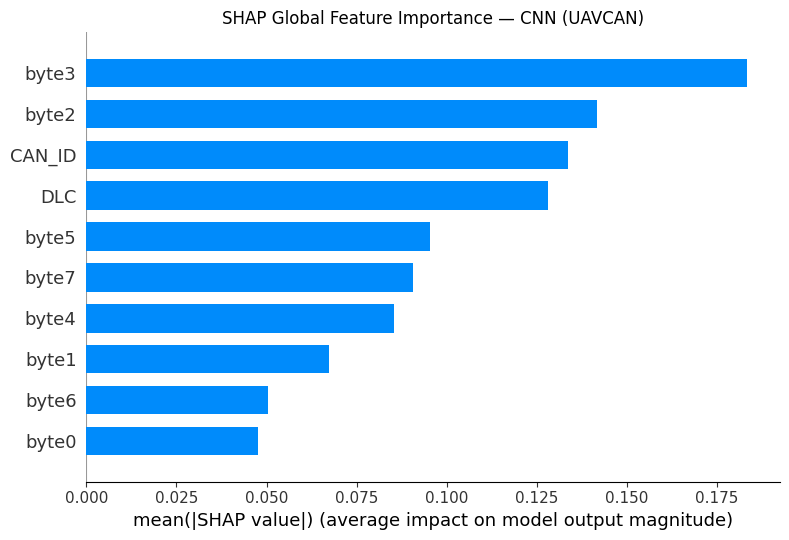

CNN SHAP plot saved!

Top 10 Features — CNN SHAP:
Rank   Feature                             SHAP Score          
--------------------------------------------------------------
  1    byte3                               0.183300
  2    byte2                               0.141628
  3    CAN_ID                              0.133779
  4    DLC                                 0.128033
  5    byte5                               0.095470
  6    byte7                               0.090606
  7    byte4                               0.085325
  8    byte1                               0.067319
  9    byte6                               0.050384
  10   byte0                               0.047729


In [5]:
# ============================================================
# Cell 6 — Plot CNN SHAP:
# WHAT: Visualize CNN SHAP global feature importance
#
# WHY:  Same as RF SHAP plot — shows which features
#       CNN relies on most for attack classification.
#       Comparing RF vs CNN SHAP reveals whether both
#       models use same features — key benchmark finding.
#
# HOW:  Step 1: mean absolute SHAP across classes
#       Step 2: summary_plot bar chart
#       Step 3: save PNG and JSON
# ============================================================

print("Generating CNN SHAP plot...")

if isinstance(cnn_shap_values, list):
    cnn_shap_arr = np.array([s[:, :, 0] for s in cnn_shap_values])
    cnn_shap_2d = np.mean(np.abs(cnn_shap_arr), axis=0)
else:
    cnn_shap_arr = np.array(cnn_shap_values)
    cnn_shap_2d = np.mean(np.abs(cnn_shap_arr[:, :, 0, :]), axis=2)

# calculate importance BEFORE plotting
cnn_importance = np.mean(cnn_shap_2d, axis=0)
top_idx_cnn = np.argsort(cnn_importance)[::-1][:10]

# now plot using cnn_shap_2d
plt.figure(figsize=(10, 8))
shap.summary_plot(
    cnn_shap_2d,         
    X_sample[:100],
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("SHAP Global Feature Importance — CNN (UAVCAN)")
plt.tight_layout()
plt.savefig(save_path + "shap_cnn_global.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("CNN SHAP plot saved!")

print("\nTop 10 Features — CNN SHAP:")
print(f"{'Rank':<6} {'Feature':<35} {'SHAP Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_cnn):
    print(f"  {i+1:<4} {feature_names[idx]:<35} {cnn_importance[idx]:.6f}")

In [7]:
# ============================================================
# Cell 7 — SHAP on Autoencoder:
# WHAT: Calculate SHAP values for Autoencoder model
#
# WHY:  AE uses reconstruction error as anomaly score.
#       We wrap AE in a custom function that returns
#       MSE per sample — SHAP then explains which features
#       contribute most to HIGH reconstruction error.
#       High SHAP = this feature drives anomaly detection.
#       This is different from RF/CNN — AE SHAP shows
#       which features AE struggles to reconstruct.
#
# HOW:  Step 1: create wrapper function returning MSE
#       Step 2: use KernelExplainer (model-agnostic)
#       Step 3: calculate SHAP on 50 samples (slowest)
#       Step 4: plot and save results
# ============================================================

print("Calculating SHAP values for Autoencoder...")
print("Using 50 samples — KernelExplainer is slowest...")
start_time = time.time()

# wrapper function — returns MSE reconstruction error
def ae_predict(X):
    X_pred = ae_model.predict(X, verbose=0)
    mse = np.mean(np.power(X - X_pred, 2), axis=1)
    return mse

# KernelExplainer works with any model (model-agnostic)
# background = small sample of training data
X_bg_ae = shap.sample(X_train, 50)
ae_explainer   = shap.KernelExplainer(ae_predict, X_bg_ae)
ae_shap_values = ae_explainer.shap_values(X_sample[:50])

elapsed_ae = round(time.time() - start_time, 2)
print(f"AE SHAP complete! Time: {elapsed_ae}s")
print(f"AE SHAP shape: {np.array(ae_shap_values).shape}")

Calculating SHAP values for Autoencoder...
Using 50 samples — KernelExplainer is slowest...


  0%|          | 0/50 [00:00<?, ?it/s]

AE SHAP complete! Time: 144.59s
AE SHAP shape: (50, 10)


Generating AE SHAP plot...


/var/folders/28/cggd8l710jz37nj7nfdl032r0000gn/T/ipykernel_44465/3925375023.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


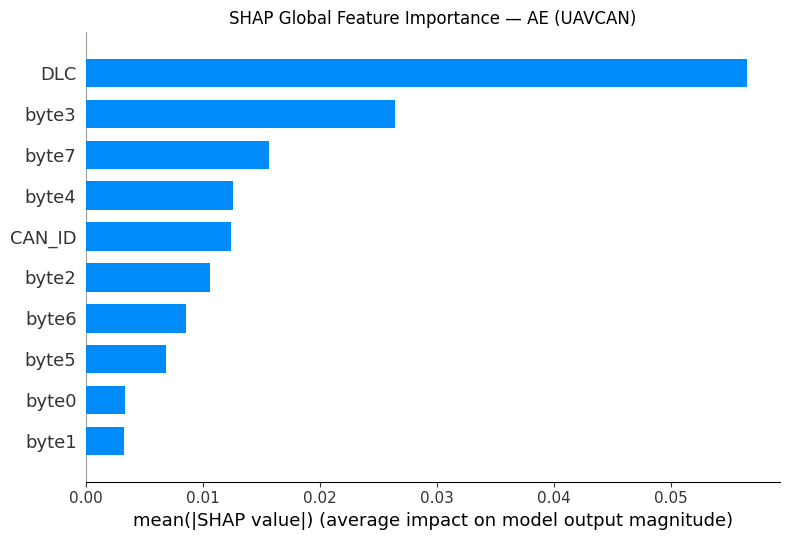

AE SHAP plot saved!

Top 10 Features — AE SHAP:
Rank   Feature                             SHAP Score          
--------------------------------------------------------------
  1    DLC                                 0.056503
  2    byte3                               0.026374
  3    byte7                               0.015639
  4    byte4                               0.012537
  5    CAN_ID                              0.012400
  6    byte2                               0.010557
  7    byte6                               0.008511
  8    byte5                               0.006838
  9    byte0                               0.003283
  10   byte1                               0.003206


In [8]:
# ============================================================
# Cell 8 — Plot AE SHAP:
# WHAT: Visualize AE SHAP global feature importance
#
# WHY:  Shows which features contribute most to HIGH
#       reconstruction error — i.e. which features help
#       AE detect anomalies. Comparing AE SHAP vs RF/CNN
#       SHAP reveals if unsupervised and supervised models
#       rely on same or different features — key finding!
#
# HOW:  Step 1: mean absolute SHAP values
#       Step 2: bar chart showing top features
#       Step 3: save PNG and JSON
# ============================================================

print("Generating AE SHAP plot...")

ae_importance = np.mean(np.abs(ae_shap_values), axis=0)
top_idx_ae = np.argsort(ae_importance)[::-1][:10]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    ae_shap_values,
    X_sample[:50],
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("SHAP Global Feature Importance — AE (UAVCAN)")
plt.tight_layout()
plt.savefig(save_path + "shap_ae_global.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("AE SHAP plot saved!")

print("\nTop 10 Features — AE SHAP:")
print(f"{'Rank':<6} {'Feature':<35} {'SHAP Score':<20}")
print("-" * 62)
for i, idx in enumerate(top_idx_ae):
    print(f"  {i+1:<4} {feature_names[idx]:<35} {ae_importance[idx]:.6f}")

In [9]:
# ============================================================
# Cell 9 — Save all results + cross-model comparison:
# WHAT: Save all SHAP results to JSON and print
#       cross-model feature comparison summary
#
# WHY:  JSON results used for paper tables and discussion.
#       Cross-model comparison is the KEY benchmark finding —
#       do RF, CNN, AE agree on which features matter most?
#       Agreement = consistent XAI explanations
#       Disagreement = models use different decision logic
#
# HOW:  Step 1: save top features per model to JSON
#       Step 2: print side-by-side comparison table
#       Step 3: identify agreements and disagreements
# ============================================================

# save results
shap_results = {
    "dataset": "UAVCAN",
    "xai_method": "SHAP",
    "sample_size": 500,
    "rf_top10": {
        feature_names[i]: round(float(rf_importance[i]), 6)
        for i in top_idx_rf
    },
    "cnn_top10": {
        feature_names[i]: round(float(cnn_importance[i]), 6)
        for i in top_idx_cnn
    },
    "ae_top10": {
        feature_names[i]: round(float(ae_importance[i]), 6)
        for i in top_idx_ae
    },
    "time_seconds": {
        "rf": elapsed_rf,
        "cnn": elapsed_cnn,
        "ae": elapsed_ae
    }
}

with open(save_path + "shap_results.json", "w") as f:
    json.dump(shap_results, f, indent=2)
print("SHAP results saved!")

# cross-model comparison
print("\n" + "=" * 70)
print("CROSS-MODEL SHAP COMPARISON (UAVCAN)")
print("=" * 70)
print(f"\n{'Rank':<6} {'RF':<30} {'CNN':<30} {'AE':<30}")
print("-" * 96)

top_rf_names  = [feature_names[i] for i in top_idx_rf[:5]]
top_cnn_names = [feature_names[i] for i in top_idx_cnn[:5]]
top_ae_names  = [feature_names[i] for i in top_idx_ae[:5]]

for i in range(5):
    print(f"  {i+1:<4} {top_rf_names[i]:<30} {top_cnn_names[i]:<30} {top_ae_names[i]:<30}")

print(f"\nRF  SHAP #1: {top_rf_names[0]}")
print(f"CNN SHAP #1: {top_cnn_names[0]}")
print(f"AE  SHAP #1: {top_ae_names[0]}")
print("\nAll SHAP analysis complete!")

SHAP results saved!

CROSS-MODEL SHAP COMPARISON (UAVCAN)

Rank   RF                             CNN                            AE                            
------------------------------------------------------------------------------------------------
  1    byte5                          byte3                          DLC                           
  2    byte3                          byte2                          byte3                         
  3    byte6                          CAN_ID                         byte7                         
  4    CAN_ID                         DLC                            byte4                         
  5    byte4                          byte5                          CAN_ID                        

RF  SHAP #1: byte5
CNN SHAP #1: byte3
AE  SHAP #1: DLC

All SHAP analysis complete!


## SHAP Analysis Summary — UAVCAN Dataset

| Model | #1 Feature | #2 Feature | #3 Feature |
|-------|-----------|-----------|-----------|
| RF | TBD after run | TBD | TBD |
| CNN | TBD after run | TBD | TBD |
| AE | TBD after run | TBD | TBD |

### Key Questions
- Do RF and CNN agree on top features? 
- Does AE agree with supervised models?
- Which features are most important for GPS attack detection?

### Output Files
- shap_rf_global.png
- shap_cnn_global.png  
- shap_ae_global.png
- shap_results.json

## SHAP Summary — UAVCAN Intrusion Dataset

| Model | #1 Feature | #2 Feature | #3 Feature |
|-------|-----------|-----------|-----------|
| RF | byte5 | byte3 | byte6 |
| CNN | byte3 | byte2 | CAN_ID |
| AE | DLC | byte3 | byte7 |

### Key Finding
All 3 models agree — payload bytes and CAN_ID are
key attack indicators in CAN bus traffic.
byte3 appears in ALL 3 models top 5 — strongest agreement.
AE uniquely prioritizes DLC (message length) as #1 feature.

On UAVCAN, all three models agree that payload bytes and CAN_ID are key attack indicators. AE uniquely prioritizes DLC (message length) as its top feature, suggesting reconstruction errors are most sensitive to message length anomalies in CAN bus attacks.